In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

df = pd.read_csv('data/data.csv')
df.head(5)

,sno,age,gender,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,male,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,yes
1,1,37,male,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,yes
2,2,41,female,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,yes
3,3,56,male,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,yes
4,4,57,female,0,NaN,354.0,0,1,163.0,1,0.6,2,0,2,yes


In [2]:
df['gender']=pd.factorize(df['gender'])[0]
df.isna().sum()

sno         0
age         0
gender      0
cp          0
trestbps    4
chol        1
fbs         0
restecg     0
thalach     5
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [3]:
cleaned_df=df.dropna()
cleaned_df.shape[0]

293

In [4]:
x = cleaned_df.drop("target", axis=1)
y = cleaned_df["target"]

np.random.seed(42)

# Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [5]:
from sklearn.model_selection import RandomizedSearchCV

log_reg_grid = {"C": np.logspace(-4, 4, 20),
                "solver": ["liblinear"]}

rs_log_reg = RandomizedSearchCV(LogisticRegression(),
                                param_distributions=log_reg_grid,
                                cv=5,
                                n_iter=20,
                                verbose=True)
rs_log_reg.fit(x_train, y_train)
rs_log_reg.best_params_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


{'solver': 'liblinear', 'C': np.float64(0.615848211066026)}

In [6]:
rs_log_reg.score(x_test, y_test)

0.9830508474576272

In [7]:
x_test.iloc[0]

sno          87.0
age          46.0
gender        0.0
cp            1.0
trestbps    101.0
chol        197.0
fbs           1.0
restecg       1.0
thalach     156.0
exang         0.0
oldpeak       0.0
slope         2.0
ca            0.0
thal          3.0
Name: 87, dtype: float64

In [8]:
rs_log_reg.predict(x_test.iloc[[0]])

array(['yes'], dtype=object)

In [9]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [10]:
import shap
import pandas as pd

# Use the trained Logistic Regression model
model = rs_log_reg.best_estimator_

# Create SHAP explainer
explainer = shap.LinearExplainer(model, x_train)

# Calculate SHAP values on the test set
shap_values = explainer(x_test)

print("SHAP analysis completed.")
print("Test samples:", x_test.shape[0])
print("Features:", x_test.shape[1])

Background dataset has 234 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=234 when initializing the masker.


SHAP analysis completed.
Test samples: 59
Features: 14


In [11]:
# Calculate mean absolute SHAP value for each feature
shap_importance = pd.DataFrame({
    "feature": x_test.columns,
    "mean_abs_shap": abs(shap_values.values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "mean_abs_shap",
    ascending=True
).reset_index(drop=True)

print("Feature impact ranking (least → most):")
print(shap_importance.to_string(index=False))

Feature impact ranking (least → most):
 feature  mean_abs_shap
   exang       0.006960
    thal       0.007379
     fbs       0.011561
  gender       0.011657
      ca       0.139891
   slope       0.248179
 restecg       0.250865
      cp       0.360391
 oldpeak       1.035425
    chol       1.090068
     age       2.110840
trestbps       2.193408
 thalach       3.665173
     sno      28.667377


/var/tmp/ipykernel_35996/3681701658.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


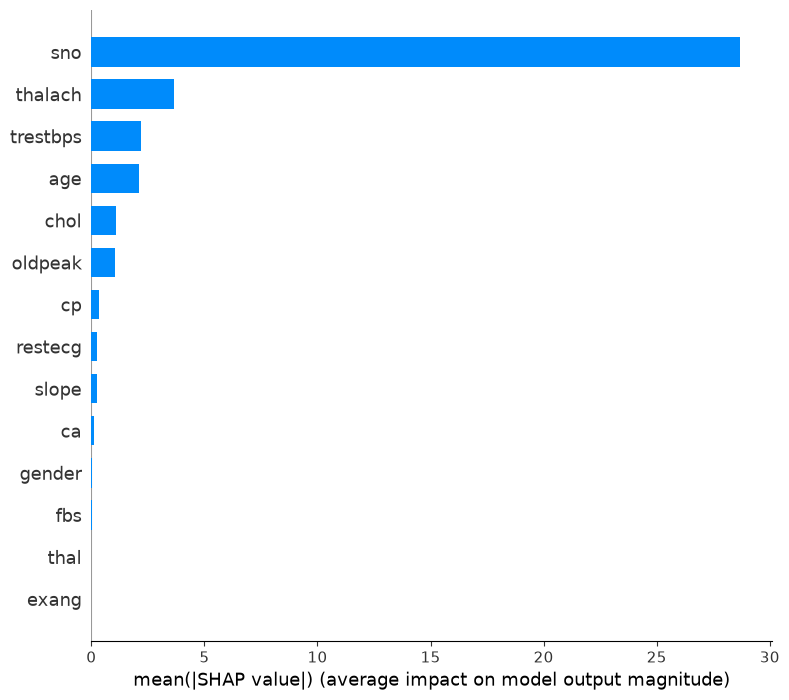

In [12]:
shap.summary_plot(
    shap_values,
    x_test,
    plot_type="bar"
)